# Project: Customer Segmentation

## Introduction
1. What is my objective?
- Clustering data using KMeans & PCA. on the customer records from a groceries firm database.

2. What business get?
- Modify products according to distinct needs and behaviours of the customers.
- Helps the business to cater to the concerns of different types of customers.

3. Understand the dataset
- Data is about groceries firm's database.
- From kaggle https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis

## 0. Set basics library & datasets

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import warnings
import sys

if not sys.warnoptions:
    warnings.simplefilter("ignore")
np.random.seed(77)

In [2]:
data = pd.read_csv(r"C:\Users\User\Desktop\Kaggle\marketing_campaign.csv", sep="\t")
print("Number of datapoints:", len(data))
data.head()

Number of datapoints: 2240


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## 1. Explore data

### 1.1 Check format & NULL

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
data["Dt_Customer"].view()

0       04-09-2012
1       08-03-2014
2       21-08-2013
3       10-02-2014
4       19-01-2014
           ...    
2235    13-06-2013
2236    10-06-2014
2237    25-01-2014
2238    24-01-2014
2239    15-10-2012
Name: Dt_Customer, Length: 2240, dtype: object

### 1.2 Format date & Clean data

In [5]:
data = data.dropna()
print("The total number of data-points after removing the rows with missing values are:", len(data))

The total number of data-points after removing the rows with missing values are: 2216


In [6]:
data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"], dayfirst=True, errors="coerce")
print("Missing:", data["Dt_Customer"].isna().sum())

Missing: 0


## 2. Feature Engineering

### 2.1 Create new feature

In [7]:
s = (data.dtypes == 'object')
object_cols = list(s[s].index)

print("Categorical variables in the dataset:", object_cols)

Categorical variables in the dataset: ['Education', 'Marital_Status']


In [8]:
print("Total categories in the feature Marital_Status:\n", data["Marital_Status"].value_counts(), "\n")
print("Total categories in the feature Education:\n", data["Education"].value_counts())

Total categories in the feature Marital_Status:
 Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64 

Total categories in the feature Education:
 Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64


In [9]:
data["Living_With"] = data["Marital_Status"].replace({"Married":"Partner", "Together":"Partner", "Absurd":"Alone", "Widow":"Alone", "YOLO":"Alone", "Divorced":"Alone", "Single":"Alone",})
data["Education"] = data["Education"].replace({"Basic":"Undergraduate", "2n Cycle":"Undergraduate", "Graduation":"Graduate", "Master":"Graduate", "PhD":"Graduate"})

In [10]:
max_date = data["Dt_Customer"].max()
data["Customer_For"] = (max_date - data["Dt_Customer"]).dt.days
data["Age"] = 2021 - data["Year_Birth"]
data["Spent"] = data["MntWines"] + data["MntFruits"] + data["MntMeatProducts"] + data["MntFishProducts"] + data["MntSweetProducts"] + data["MntGoldProds"]
data["Children"] = data["Kidhome"] + data["Teenhome"]
data["Family_Size"] = data["Living_With"].replace({"Alone": 1, "Partner":2}) + data["Children"]
data["Is_Parent"] = np.where(data.Children> 0, 1, 0)
data=data.rename(columns={"MntWines": "Wines","MntFruits":"Fruits","MntMeatProducts":"Meat","MntFishProducts":"Fish","MntSweetProducts":"Sweets","MntGoldProds":"Gold"})

to_drop = ["Marital_Status", "Dt_Customer", "Z_CostContact", "Z_Revenue", "Year_Birth", "ID", 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1','AcceptedCmp2', 'Complain', 'Response']
data = data.drop(to_drop, axis=1)

### 2.2 Clean Outliner

Reletive Plot Of Some Selected Features: A Data Subset


<Figure size 800x550 with 0 Axes>

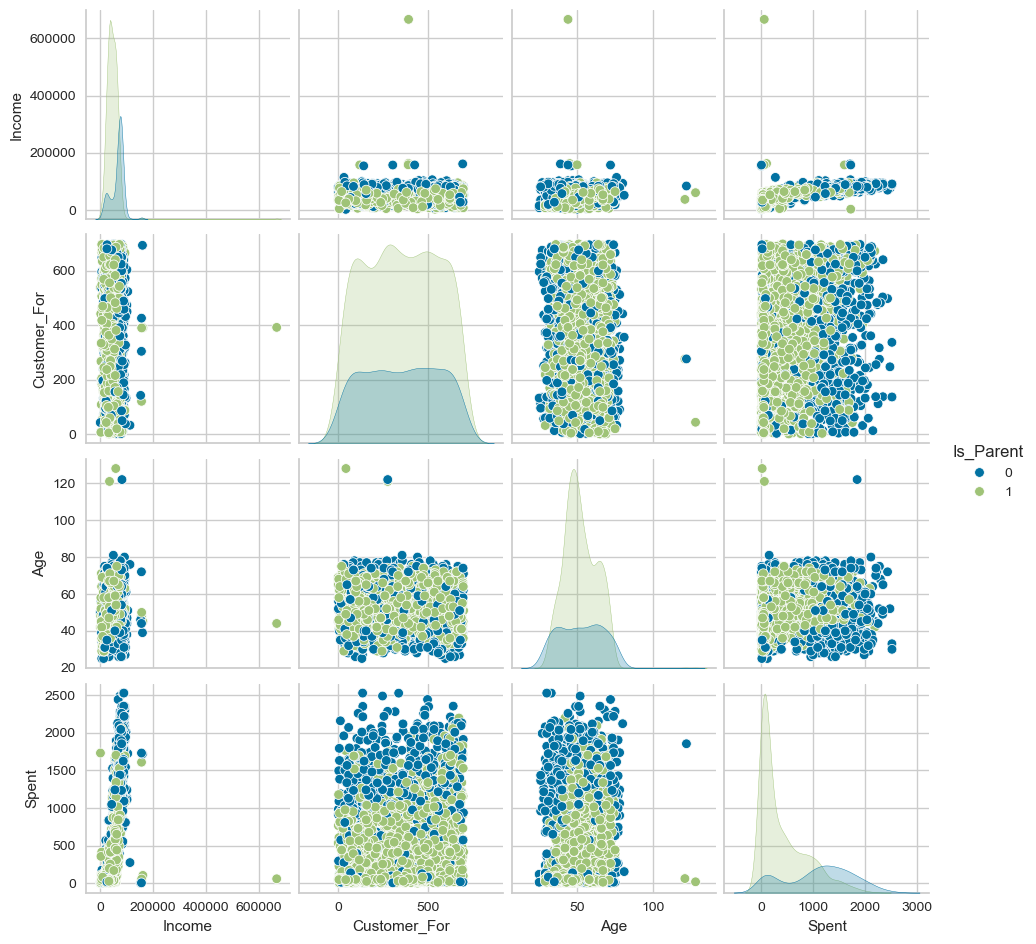

In [11]:
To_Plot = [ "Income", "Customer_For", "Age", "Spent", "Is_Parent"]
print("Reletive Plot Of Some Selected Features: A Data Subset")
plt.figure()
sns.pairplot(data[To_Plot], hue= "Is_Parent", height=2.4, aspect=1)
plt.show()

In [12]:
data = data[(data["Age"]<90)]
data = data[(data["Income"]<600000)]
print("The total number of data-points after removing the outliers are:", len(data))

The total number of data-points after removing the outliers are: 2212


### 2.3 Format categorical to numerical
- This help clustering more safety.

In [13]:
## one-hot encoder because using PCA
data = pd.get_dummies(data, columns=["Education", "Living_With"], drop_first=True)

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2212 entries, 0 to 2239
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Income                   2212 non-null   float64
 1   Kidhome                  2212 non-null   int64  
 2   Teenhome                 2212 non-null   int64  
 3   Recency                  2212 non-null   int64  
 4   Wines                    2212 non-null   int64  
 5   Fruits                   2212 non-null   int64  
 6   Meat                     2212 non-null   int64  
 7   Fish                     2212 non-null   int64  
 8   Sweets                   2212 non-null   int64  
 9   Gold                     2212 non-null   int64  
 10  NumDealsPurchases        2212 non-null   int64  
 11  NumWebPurchases          2212 non-null   int64  
 12  NumCatalogPurchases      2212 non-null   int64  
 13  NumStorePurchases        2212 non-null   int64  
 14  NumWebVisitsMonth        2212

### 2.4 Scaled data
- Using StandardScaler due to continuous numerical data such as income, age.

In [15]:
ds = data.copy()
numeric_cols = ds.select_dtypes(include=["int64", "float64"]).columns
bool_cols = ds.select_dtypes(include=["bool"]).columns

scaler = StandardScaler()
scaled_numeric = pd.DataFrame(scaler.fit_transform(ds[numeric_cols]), columns=numeric_cols)

scaled_ds = pd.concat([scaled_numeric, ds[bool_cols].reset_index(drop=True)], axis=1)

In [16]:
scaled_ds.head()

,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Customer_For,Age,Spent,Children,Family_Size,Education_Undergraduate,Living_With_Partner
0,0.287105,-0.822754,-0.929699,0.310353,0.977660,1.552041,1.690293,2.453472,1.483713,0.852576,...,2.503607,-0.555814,0.692181,1.527721,1.018352,1.676245,-1.264598,-1.758359,False,False
1,-0.260882,1.040021,0.908097,-0.380813,-0.872618,-0.637461,-0.718230,-0.651004,-0.634019,-0.733642,...,-0.571340,-1.171160,-0.132545,-1.189011,1.274785,-0.963297,1.404572,0.449070,False,False
2,0.913196,-0.822754,-0.929699,-0.795514,0.357935,0.570540,-0.178542,1.339513,-0.147184,-0.037254,...,-0.229679,1.290224,-0.544908,-0.206048,0.334530,0.280110,-1.264598,-0.654644,False,True
3,-1.176114,1.040021,-0.929699,-0.795514,-0.872618,-0.561961,-0.655787,-0.504911,-0.585335,-0.752987,...,-0.913000,-0.555814,0.279818,-1.060584,-1.289547,-0.920135,0.069987,0.449070,False,True
4,0.294307,1.040021,-0.929699,1.554453,-0.392257,0.419540,-0.218684,0.152508,-0.001133,-0.559545,...,0.111982,0.059532,-0.132545,-0.951915,-1.033114,-0.307562,0.069987,0.449070,False,True


## 3. Dimension Reduction

### 3.1 PCA
- PCA is fitted for high dimensional (more feature) & good for machine learning model.
- More PCA component is good for explained but use more time too.

In [17]:
pca = PCA(n_components=10)
pca.fit(scaled_ds)
PCA_ds = pd.DataFrame(pca.transform(scaled_ds))

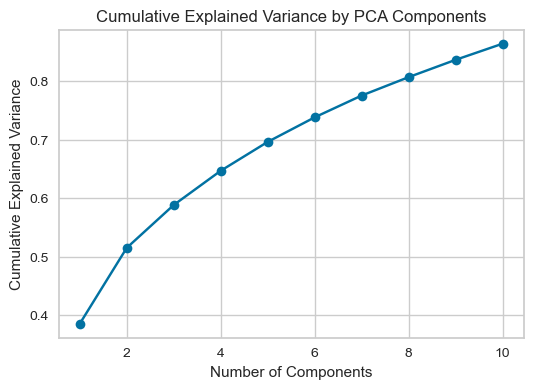

In [18]:
plt.figure(figsize=(6,4))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_.cumsum(), marker='o')
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

### 3.2 KMeans
- Suitable for grouping without having to be told by humans.
- The best amount of grouping (optimal k) is 6 groups.

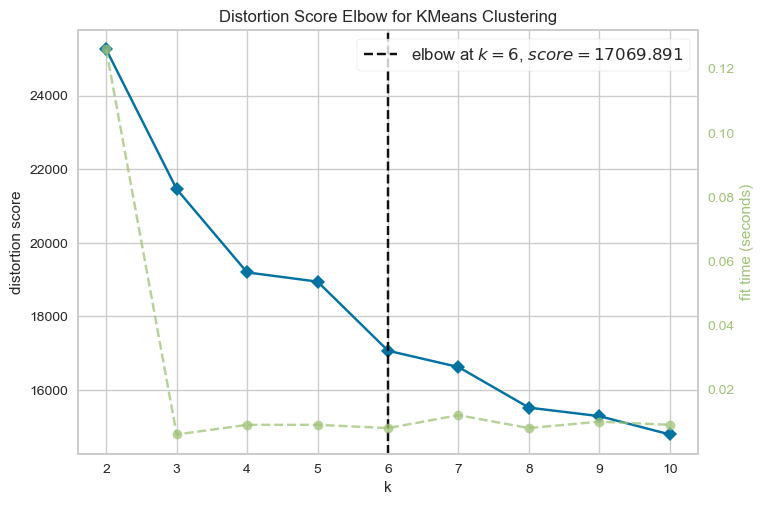

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [19]:
Elbow_M = KElbowVisualizer(KMeans(), k=10)
Elbow_M.fit(PCA_ds)
Elbow_M.show()

In [22]:
kmeans = KMeans(n_clusters=6, random_state=77)
clusters = kmeans.fit_predict(PCA_ds)
PCA_ds["Clusters"] = clusters
data["Clusters"] = clusters

### 3.3 Visualize Clusters

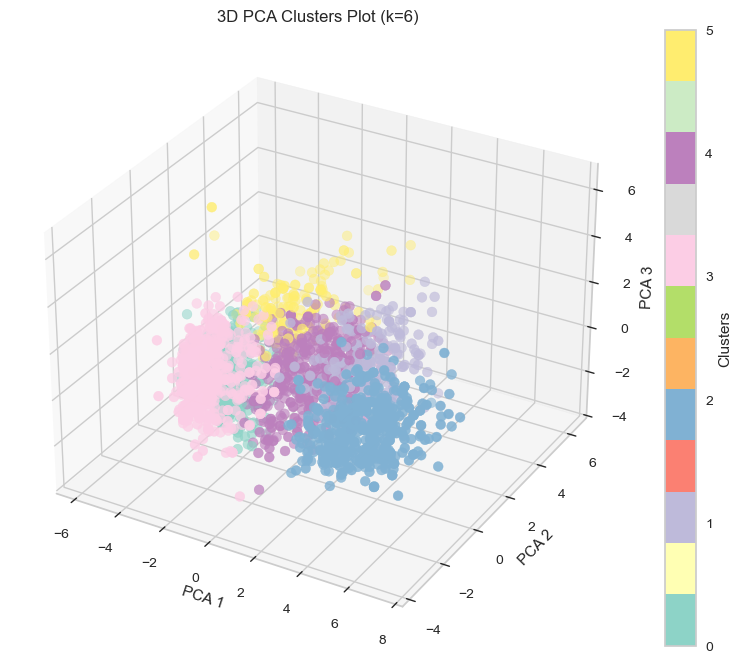

In [23]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

x = PCA_ds[0]
y = PCA_ds[1]
z = PCA_ds[2]

sc = ax.scatter(x, y, z, c=clusters, cmap="Set3", s=50)
ax.set_title("3D PCA Clusters Plot (k=6)")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
plt.colorbar(sc, label="Clusters")
plt.show()

In [24]:
import plotly.express as px

fig = px.scatter_3d(PCA_ds, x=0, y=1, z=2, color="Clusters", opacity=0.7)
fig.update_layout(title="3D PCA Clusters")
fig.show()

## 4. Analyze

### 4.1 Classify each cluster to class
- This help other employee easy to understand for dealing with customer.

| Cluster | Age | Income | Spent | Time | Parent | Group (Age, Income, Spent, Time) | Class (Parent, Group) |
|:--------|:--------|:--------|:--------|:--------|:--------|:--------|:--------|
| 0 | ~56 | ~40000 | ~100 | ~250 | All Parent | Mid, Low, Low, Mid | Elder Parent Saver |
| 1 | ~52 | ~70000 | ~1000 | ~500 | High Parent | Mid, High, High, High | Loyal Mid Parent Affluent |
| 2 | ~52 | ~78000 | ~1500 | ~300 | Little Parent | Mid, High, High, Mid | Mid Not Parent Top Spender |
| 3 | ~43 | ~30000 | ~100 | ~300 | High Parent | Low, Low, Low, Mid | Young Parent Saver |
| 4 | ~58 | ~60000 | ~600 | ~300 | High Parent | High, Mid, Mid, Mid | Elder Parent Balance |
| 5 | ~52 | ~50000 | ~500 | ~500 | High Parent | Mid, Mid, Mid, High | Loyal Mid Parent Balance |

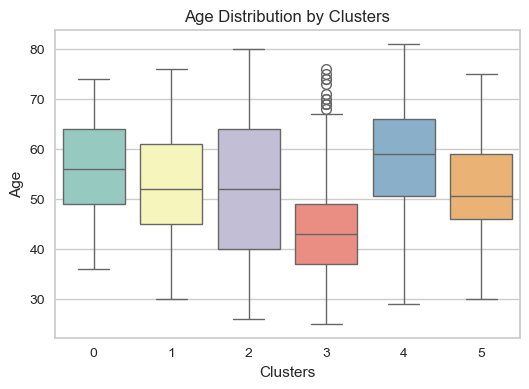

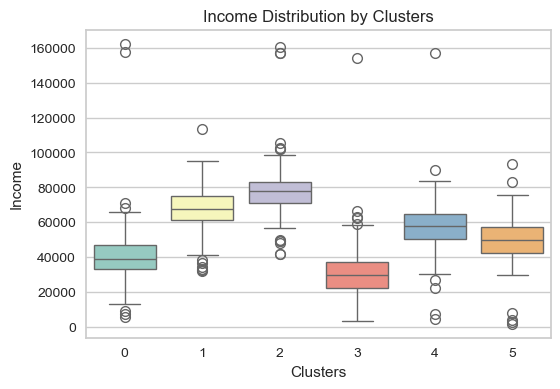

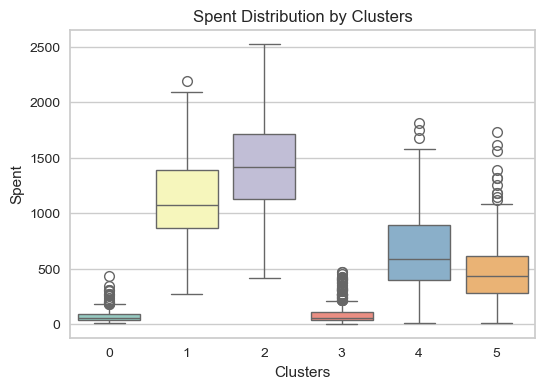

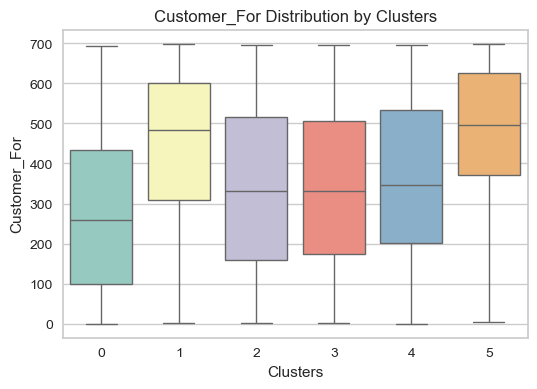

In [26]:
features = ["Age", "Income", "Spent", "Customer_For"]
for feature in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Clusters", y=feature, data=data, palette="Set3")
    plt.title(f"{feature} Distribution by Clusters")
    plt.show()

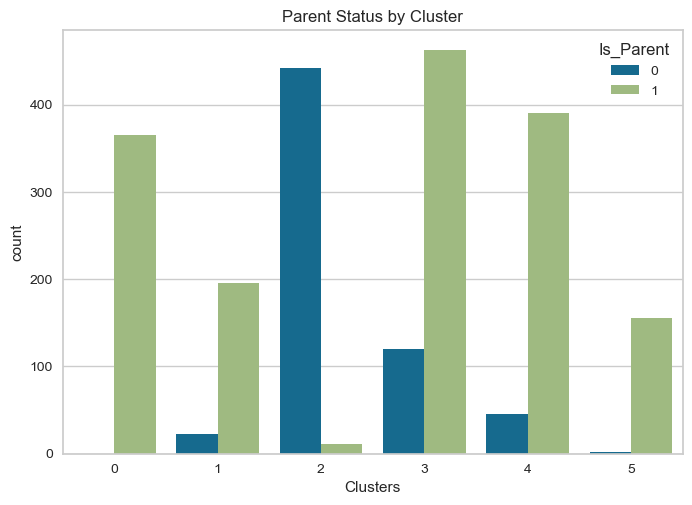

In [ ]:
sns.countplot(x="Clusters", hue="Is_Parent", data=data)
plt.title("Parent Status by Cluster")
plt.show()

In [28]:
data.groupby('Clusters')[["Age", "Income", "Spent", "Customer_For"]].mean()

,Age,Income,Spent,Customer_For
Clusters,,,,
0,56.298630,40289.775342,76.208219,278.789041
1,52.972603,67362.547945,1135.205479,447.232877
2,52.580574,77806.953642,1431.147903,340.821192
3,43.850515,29931.879725,94.946735,341.731959
4,58.448276,57413.103448,655.149425,357.009195
5,52.531646,49576.702532,495.518987,469.208861


In [29]:
data.groupby('Clusters')['Is_Parent'].value_counts(normalize=True)

Clusters  Is_Parent
0         1            1.000000
1         1            0.894977
          0            0.105023
2         0            0.975717
          1            0.024283
3         1            0.793814
          0            0.206186
4         1            0.896552
          0            0.103448
5         1            0.987342
          0            0.012658
Name: proportion, dtype: float64

### 4.2 Profiling

| Cluster | Children | Family_Size | Education | With_Partner | Type |
|:--------|:--------|:--------|:--------|:--------|:--------|
| 0 | 1~3 | 2~5 | Mixed | Mixed | Family Mixed |
| 1 | ~1 | 2~3 | Mostly Graduate | Mixed | Graduate Small Family |
| 2 | ~0 | 1~2 | Mostly Graduate | Mixed | Graduate Living Alone |
| 3 | 0~1 | 1~3 | Mixed | Mixed | Living Alone Mixed |
| 4 | 1~3 | 2~4 | Mostly Graduate | Mixed | Graduate Mid Family |
| 5 | 1~2 | 3~4 | Mostly Graduate | Mixed | Graduate Mid Family |

<Figure size 800x550 with 0 Axes>

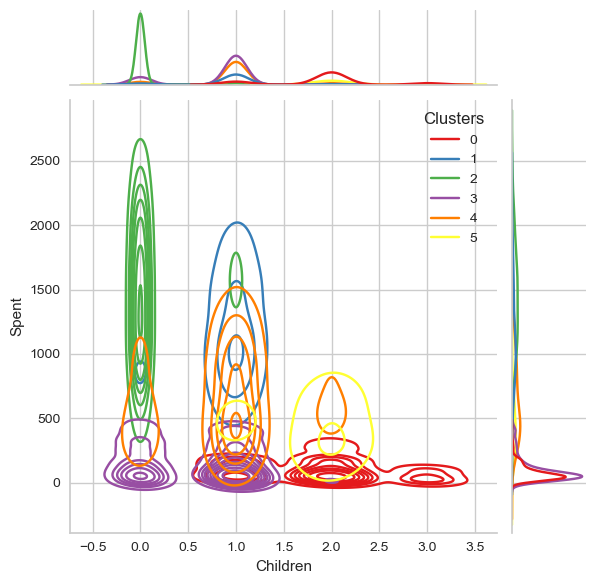

<Figure size 800x550 with 0 Axes>

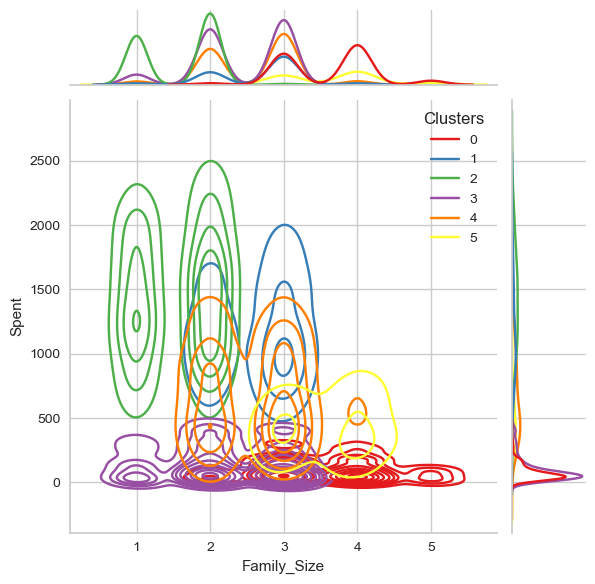

<Figure size 800x550 with 0 Axes>

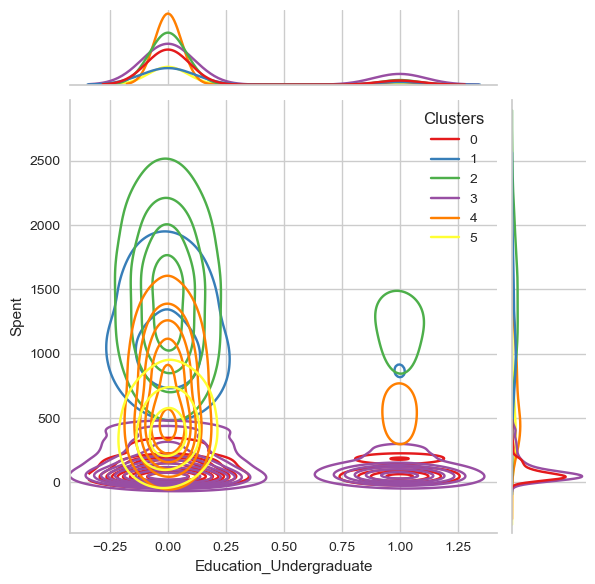

<Figure size 800x550 with 0 Axes>

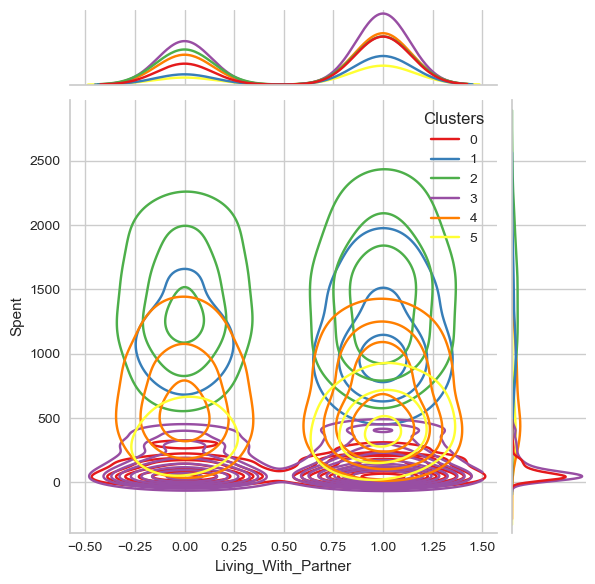

In [31]:
Personal = [ "Children", "Family_Size", "Education_Undergraduate","Living_With_Partner"]

for i in Personal:
    plt.figure()
    sns.jointplot(x=data[i], y=data["Spent"], hue =data["Clusters"], kind="kde", palette="Set1")
    plt.show()

### 4.3 Define Cluster

| Cluster | Type | Class | Definition |
|:--------|:--------|:--------|:--------|
| 0 | Family Mixed | Elder Parent Saver | Older customers with families or children — low spending |
| 1 | Graduate Small Family | Loyal Mid Parent Affluent | Small families with high income and educated — loyal and high spending |
| 2 | Graduate Living Alone | Mid Not Parent Top Spender | Singles or couple with high income and educated — high spending |
| 3 | Living Alone Mixed | Young Parent Saver | Young single or with small families — low spending |
| 4 | Graduate Mid Family | Elder Parent Balance | Elder middle families with moderate income and educated — moderate spending |
| 5 | Graduate Mid Family | Loyal Mid Parent Balance |  Middle families with moderate income and educated — loyal and moderate spending |

### 4.4 Summary

| Cluster | Definition | Insight |
|:--------|:--------|:--------|
| 0 | Older customers with families or children — low spending | Discount promotions or family campaigns |
| 1 | Small families with high income and educated — loyal and high spending | Premium products and loyalty programs |
| 2 | Singles or couple with high income and educated — high spending | Lifestyle products or personal services such as fashion, technology |
| 3 | Young single or with small families — low spending | Value-oriented marketing or initial promotions for new customers |
| 4 | Elder middle families with moderate income and educated — moderate spending | Suitable for family and health products |
| 5 | Middle families with moderate income and educated — loyal and moderate spending | Membership programs or subscription services |

| Cluster | % Customer | % Spending | Analyze | Strategy |
|:--------|:--------|:--------|:--------|:--------|
| 0 | 16.5% | 2.1% | Many customers but little spending | Low Spending Group with Large Customer Base — Growth Opportunity |
| 1 | 9.9% | 18.5% | Few customers but lots of usage | High-spending groups should invest in loyalty |
| 2 | 20.5% | 48.3% | The most important group, highest spender | Highest Spending Group (Must Maintain + Develop) |
| 3 | 26.3% | 4.1% | Many customers but low spending | Low Spending Group with Large Customer Base — Growth Opportunity |
| 4 | 19.7% | 21.2% | Customers and spending are relatively balanced | High-spending groups should invest in loyalty |
| 5 | 7.1% | 5.8% | Small group, low spending | It may not be necessary to invest much if there is no opportunity to add value |

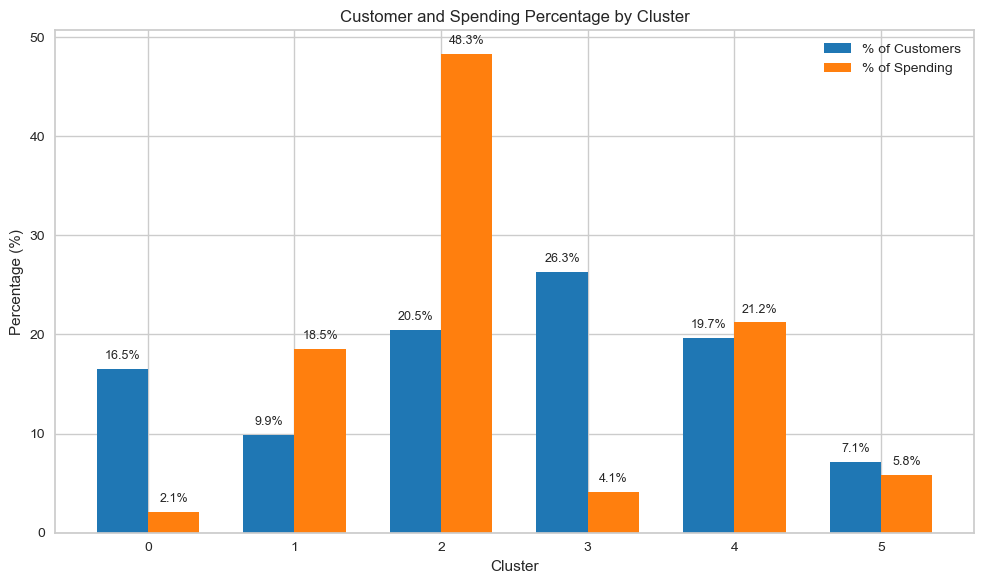

In [ ]:
cluster_counts = data["Clusters"].value_counts(normalize=True).sort_index() * 100
cluster_spent = data.groupby("Clusters")["Spent"].sum()
cluster_spent_percent = cluster_spent / cluster_spent.sum() * 100

clusters = cluster_counts.index.astype(str)
x = range(len(clusters))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bar1 = ax.bar([i - width/2 for i in x], cluster_counts, width, label='% of Customers', color="#1f77b4")
bar2 = ax.bar([i + width/2 for i in x], cluster_spent_percent, width, label='% of Spending', color="#ff7f0e")

ax.set_xlabel('Cluster')
ax.set_ylabel('Percentage (%)')
ax.set_title('Customer and Spending Percentage by Cluster')
ax.set_xticks(x)
ax.set_xticklabels(clusters)
ax.legend()

for i in x:
    ax.text(i - width/2, cluster_counts[i] + 1, f'{cluster_counts[i]:.1f}%', ha='center', fontsize=9)
    ax.text(i + width/2, cluster_spent_percent[i] + 1, f'{cluster_spent_percent[i]:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Conclude
1. Our data has NUll, outliner and non-format data to manage.
2. Create new feature using feature engineering to make cluster and interpretation more better.
3. Use PCA to reduce the dimension for KMeans clustering which classify into 6 group.
4. Customers mostly parent, old and various type.
5. There are much oppurtunities to increase customer spending and loyalty.